<a href="https://colab.research.google.com/github/unatardedemartes-a11y/ClassFiles/blob/main/Matematicas_semana6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

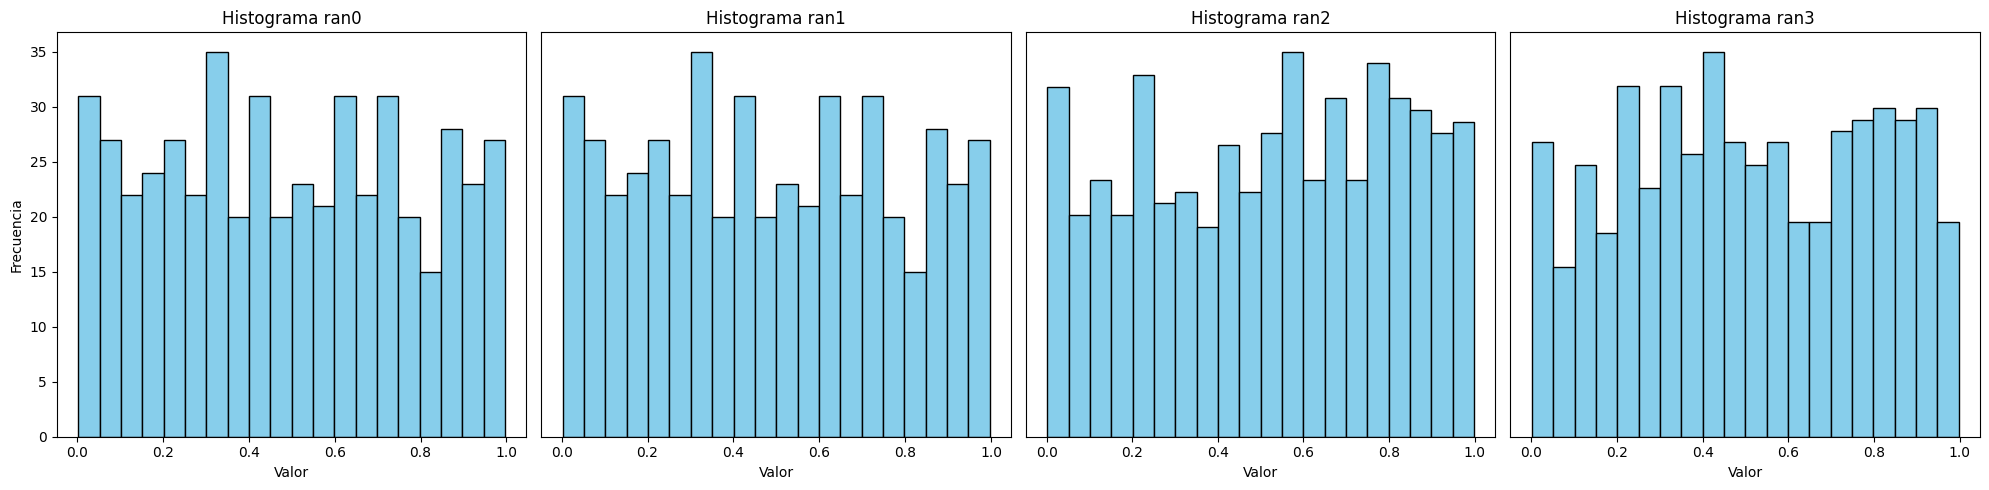

In [7]:
import matplotlib.pyplot as plt

# ==========================================
# 1. DEFINICIÓN DE LOS 4 GENERADORES
# ==========================================

class Ran0:
    def __init__(self, semilla=12345):
        self.m = 2147483647
        self.a = 16807
        self.semilla = semilla % self.m
        if self.semilla == 0: self.semilla = 1

    def next(self):
        self.semilla = (self.a * self.semilla) % self.m
        return self.semilla / self.m

class Ran1:
    def __init__(self, semilla=12345):
        self.m = 2147483647
        self.a = 16807
        self.semilla = semilla % self.m
        if self.semilla == 0: self.semilla = 1

        self.tabla = [0] * 97
        for i in range(97):
            self.semilla = (self.a * self.semilla) % self.m
            self.tabla[i] = self.semilla
        self.indice = 96

    def next(self):
        self.semilla = (self.a * self.semilla) % self.m
        j = self.indice % 97
        self.indice = (self.indice + 1) % 97
        temp = self.tabla[j]
        self.tabla[j] = self.semilla
        return temp / self.m

class Ran2:
    def __init__(self, semilla=12345):
        self.m1 = 2147483563
        self.a1 = 40014
        self.m2 = 2147483399
        self.a2 = 40692

        self.semilla1 = semilla % self.m1
        self.semilla2 = semilla % self.m2
        if self.semilla1 == 0: self.semilla1 = 1
        if self.semilla2 == 0: self.semilla2 = 1

        self.tabla = [0] * 64
        for i in range(64):
            self.semilla1 = (self.a1 * self.semilla1) % self.m1
            self.tabla[i] = self.semilla1
        self.indice = 63

    def next(self):
        self.semilla1 = (self.a1 * self.semilla1) % self.m1
        self.semilla2 = (self.a2 * self.semilla2) % self.m2
        j = self.indice % 64
        self.indice = (self.indice + 1) % 64
        temp = self.tabla[j]
        self.tabla[j] = (self.semilla1 - self.semilla2) % self.m1
        if temp < 1:
            return (temp + self.m1 - 1) / self.m1
        else:
            return (temp - 1) / self.m1

class Ran3:
    def __init__(self, semilla=12345):
        self.mbigu = 1000000000
        self.mseed = 161803398
        self.ma = [0] * 56

        mj = self.mseed - semilla
        self.ma[55] = mj
        mk = 1

        for i in range(1, 55):
            ii = (21 * i) % 55
            self.ma[ii] = mk
            mk = mj - mk
            if mk < 0: mk += self.mbigu
            mj = self.ma[ii]

        for _ in range(4):
            for i in range(1, 56):
                self.ma[i] -= self.ma[1 + (i + 30) % 55]
                if self.ma[i] < 0: self.ma[i] += self.mbigu

        self.indice1 = 0
        self.indice2 = 31

    def next(self):
        self.indice1 = (self.indice1 + 1) % 56
        self.indice2 = (self.indice2 + 1) % 56
        self.ma[self.indice1] -= self.ma[self.indice2]
        if self.ma[self.indice1] < 0: self.ma[self.indice1] += self.mbigu
        return self.ma[self.indice1] / self.mbigu

# ==========================================
# 2. GENERACIÓN DE DATOS (500 números)
# ==========================================

N = 500  # <--- Cambiado a 500 como pediste
generadores = {
    'ran0': Ran0(12345),
    'ran1': Ran1(12345),
    'ran2': Ran2(12345),
    'ran3': Ran3(12345)
}

datos = {}
for nombre, gen in generadores.items():
    datos[nombre] = [gen.next() for _ in range(N)]

# ==========================================
# 3. GRÁFICAS (Solo histogramas)
# ==========================================

# Crear una figura con 1 fila y 4 columnas
fig, axes = plt.subplots(1, 4, figsize=(20, 5))

# Generar un histograma para cada generador
for i, (nombre, vals) in enumerate(datos.items()):
    ax = axes[i]
    ax.hist(vals, bins=20, color='skyblue', edgecolor='black') # 20 barras está bien para 500 datos
    ax.set_title(f'Histograma {nombre}')
    ax.set_xlabel('Valor')
    if i == 0:
        ax.set_ylabel('Frecuencia')
    else:
        ax.set_yticks([]) # Ocultar el eje Y en las demás para que se vea más limpio

plt.tight_layout()
plt.show()

RESULTADOS DE LA SIMULACIÓN (N = 100,000 lanzamientos)
Evento                    Teórico      Experimental    Error
--------------------------------------------------
Suma = 7                  0.16667      0.16894         0.00227
Suma > 10                 0.08333      0.08302         0.00031


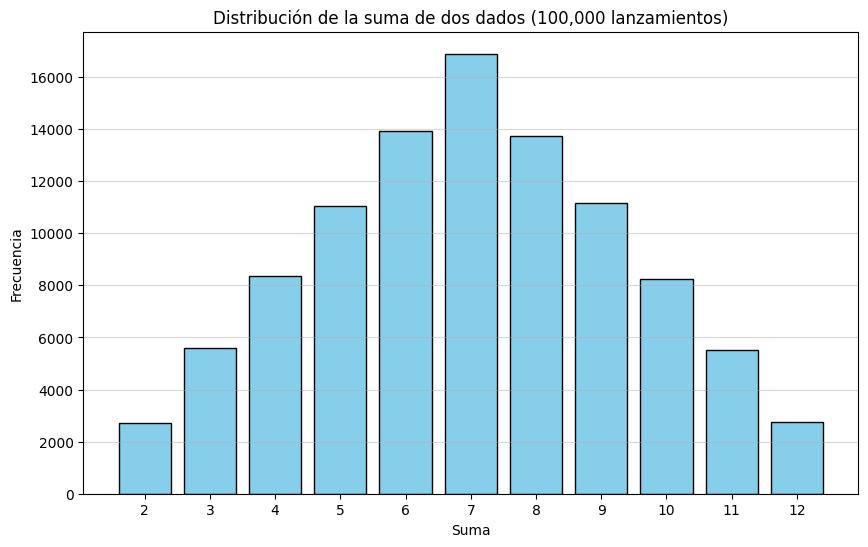

In [8]:
import random
import matplotlib.pyplot as plt

# ==========================================
# 1. FUNCIÓN DE SIMULACIÓN
# ==========================================

def simular_dados(n_lanzamientos):
    """
    Simula n_lanzamientos de dos dados.
    Devuelve dos listas: una con las sumas, y otra con los resultados booleanos
    de si la suma fue > 10.
    """
    sumas = []
    mayores_10 = 0
    sumas_7 = 0

    for _ in range(n_lanzamientos):
        d1 = random.randint(1, 6)
        d2 = random.randint(1, 6)
        suma = d1 + d2
        sumas.append(suma)

        if suma == 7:
            sumas_7 += 1
        if suma > 10:
            mayores_10 += 1

    return sumas, sumas_7, mayores_10

# ==========================================
# 2. EJECUCIÓN Y COMPARACIÓN
# ==========================================

# Definir el número de simulaciones (mientras más, mejor)
N = 100000  # 100,000 lanzamientos

# Ejecutar la simulación
sumas, conteo_7, conteo_mayor_10 = simular_dados(N)

# Calcular probabilidades experimentales
prob_7_exp = conteo_7 / N
prob_mayor_10_exp = conteo_mayor_10 / N

# Valores teóricos
prob_7_teorica = 1/6
prob_mayor_10_teorica = 1/12

# Mostrar resultados
print(f"{'='*50}")
print(f"RESULTADOS DE LA SIMULACIÓN (N = {N:,} lanzamientos)")
print(f"{'='*50}")
print(f"{'Evento':<25} {'Teórico':<12} {'Experimental':<15} {'Error'}")
print(f"{'-'*50}")
print(f"{'Suma = 7':<25} {prob_7_teorica:<12.5f} {prob_7_exp:<15.5f} {abs(prob_7_teorica - prob_7_exp):.5f}")
print(f"{'Suma > 10':<25} {prob_mayor_10_teorica:<12.5f} {prob_mayor_10_exp:<15.5f} {abs(prob_mayor_10_teorica - prob_mayor_10_exp):.5f}")
print(f"{'='*50}")

# ==========================================
# 3. GRÁFICA DE LA DISTRIBUCIÓN DE SUMAS
# ==========================================

plt.figure(figsize=(10, 6))
plt.hist(sumas, bins=range(2, 14), edgecolor='black', align='left', rwidth=0.8, color='skyblue')
plt.title(f'Distribución de la suma de dos dados ({N:,} lanzamientos)')
plt.xlabel('Suma')
plt.ylabel('Frecuencia')
plt.xticks(range(2, 13))
plt.grid(axis='y', alpha=0.5)
plt.show()